In [48]:
# autoreload 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from co60.loaders import load_run_configs, find_greatest_common_count_num
from co60.bin import establish_binning 
from co60.calibration import establish_gaussian_calibration_co60, copy_calibration
from co60.count import collect_coincidence_counts, collect_single_trigger_counts

In [50]:
RUN_CONFIGS_COINC_1June2026 = load_run_configs(cache_key="coincidence_trial_1June2026_load_run")

CH1_TRIGGER_RUN_CONFIGS_1June2026 = load_run_configs(cache_key="CH1_trig_trial_1June2026_load_run_single_trigger")

CH2_TRIGGER_RUN_CONFIGS_1June2026 = load_run_configs(cache_key="CH2_trig_trial_1June2026_load_run_single_trigger")

[loaders] Cache hit — loading 'coincidence_trial_1June2026_load_run' from C:\Users\pomar\OneDrive\Desktop\Javier_Ang_Corr_Project\co60_angular_correlation\cache\coincidence_trial_1June2026_load_run.pkl
[loaders] Cache hit — loading 'CH1_trig_trial_1June2026_load_run_single_trigger' from C:\Users\pomar\OneDrive\Desktop\Javier_Ang_Corr_Project\co60_angular_correlation\cache\CH1_trig_trial_1June2026_load_run_single_trigger.pkl
[loaders] Cache hit — loading 'CH2_trig_trial_1June2026_load_run_single_trigger' from C:\Users\pomar\OneDrive\Desktop\Javier_Ang_Corr_Project\co60_angular_correlation\cache\CH2_trig_trial_1June2026_load_run_single_trigger.pkl


In [51]:
n_common = find_greatest_common_count_num(RUN_CONFIGS_COINC_1June2026)

for run in RUN_CONFIGS_COINC_1June2026:
    run["loaded_run"].truncate(n_common)

n_common = find_greatest_common_count_num(CH1_TRIGGER_RUN_CONFIGS_1June2026)

for run in CH1_TRIGGER_RUN_CONFIGS_1June2026:
    run["loaded_run"].truncate(n_common)

n_common = find_greatest_common_count_num(CH2_TRIGGER_RUN_CONFIGS_1June2026)

for run in CH2_TRIGGER_RUN_CONFIGS_1June2026:
    run["loaded_run"].truncate(n_common)

In [52]:
RUN_CONFIGS_COINC_1June2026_BINNED = establish_binning(RUN_CONFIGS_COINC_1June2026)

In [53]:
display(RUN_CONFIGS_COINC_1June2026_BINNED)

[{'fname': 'C:\\Users\\pomar\\OneDrive\\Desktop\\Javier_Ang_Corr_Project\\06-01-2026/coincidence/co60_coincidence_trial_CH1_HV0_300+020_CH2+HV1_437+290_90deg_source_25cm_away_1June2026.dat',
  'angle': 90.0,
  'loaded_run': RunData(angle_deg=90.0, fname='C:\\Users\\pomar\\OneDrive\\Desktop\\Javier_Ang_Corr_Project\\06-01-2026/coincidence/co60_coincidence_trial_CH1_HV0_300+020_CH2+HV1_437+290_90deg_source_25cm_away_1June2026.dat', board_id=3067, channels={1: ChannelEvents(energy=array([133.11102513,  43.40294227,  97.27788746, ..., 126.43830311,
          46.82089607, 130.81768487]), pedestal=array([-0.00382124, -0.00406693, -0.00343385, ..., -0.00363221,
         -0.00259867, -0.00380318]), tthresh=array([180.29972341, 174.92318299, 184.78632163, ..., 184.03272666,
         185.81870179, 180.86551503])), 2: ChannelEvents(energy=array([ 56.95530545,  63.77344871, 107.6184054 , ..., 109.89811738,
          32.92479317,  53.45601171]), pedestal=array([-0.00445743, -0.00446958, -0.00238068

In [54]:
RUN_CONFIGS_COINC_1June2026_CALIB = establish_gaussian_calibration_co60(RUN_CONFIGS_COINC_1June2026_BINNED)

C:\Users\pomar\OneDrive\Desktop\Javier_Ang_Corr_Project\co60_angular_correlation\src\co60\calibration.py:121: OptimizeWarning: Covariance of the parameters could not be estimated
  (m, b), _ = curve_fit(line, uncalib_centers, TRUE_ENERGIES)


The following is a fragile part of the pipeline, it requires someone to manually determine the Co-60 tolerances which best cover the Co-60 peaks, and pass this in as an argument to the function of co60.calibration.

This is done here with dict `co60_tols`.

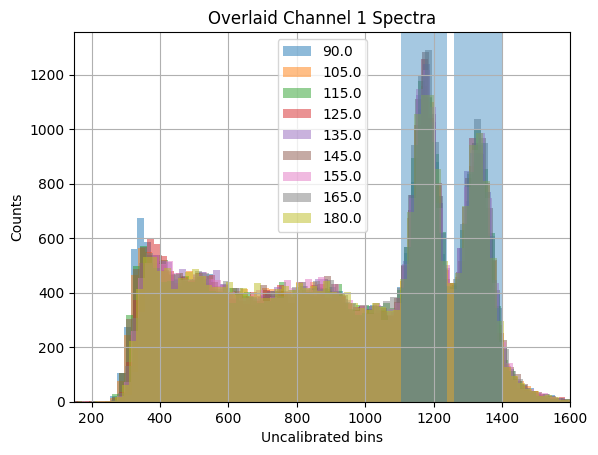

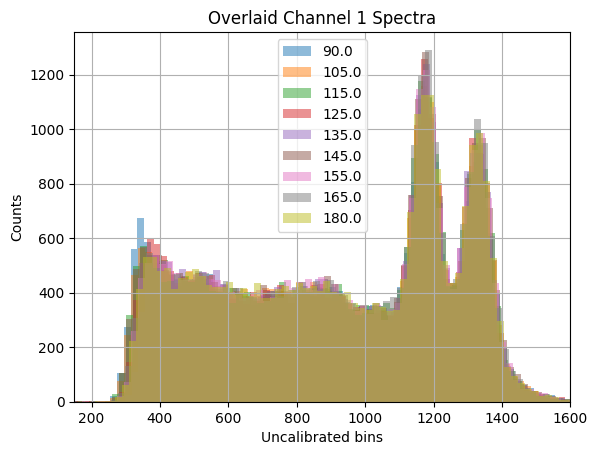

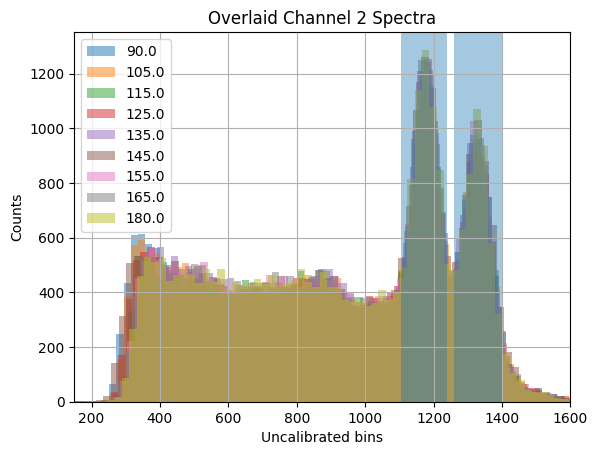

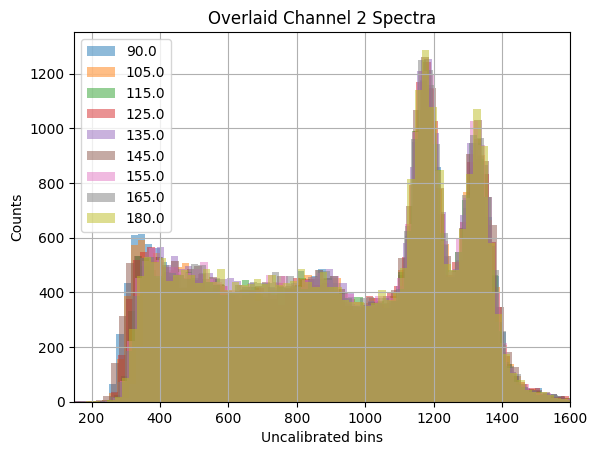

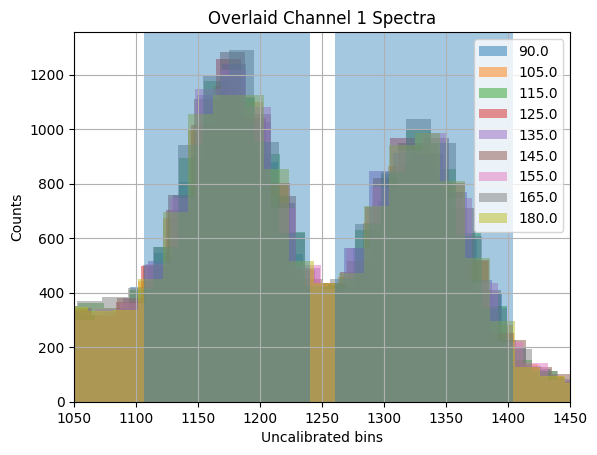

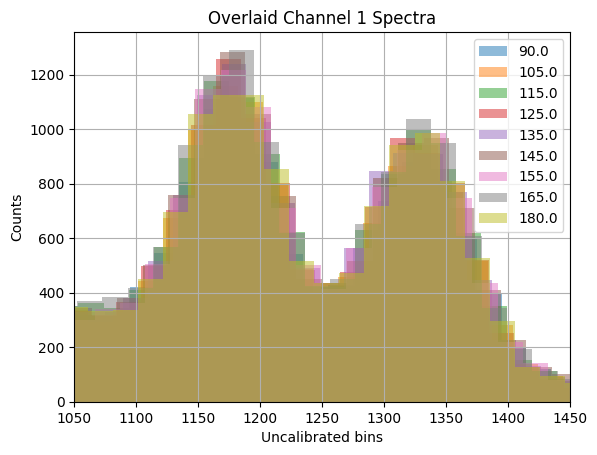

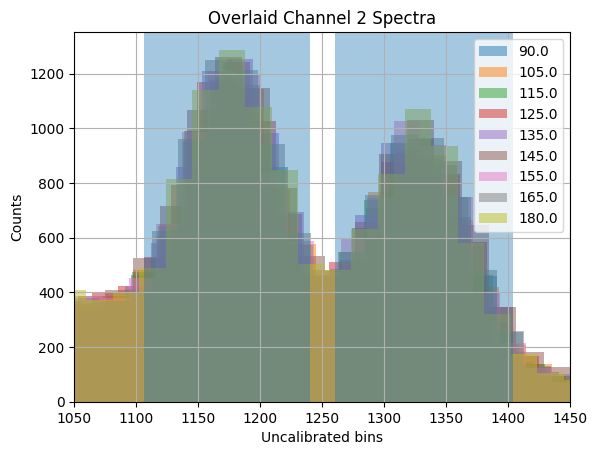

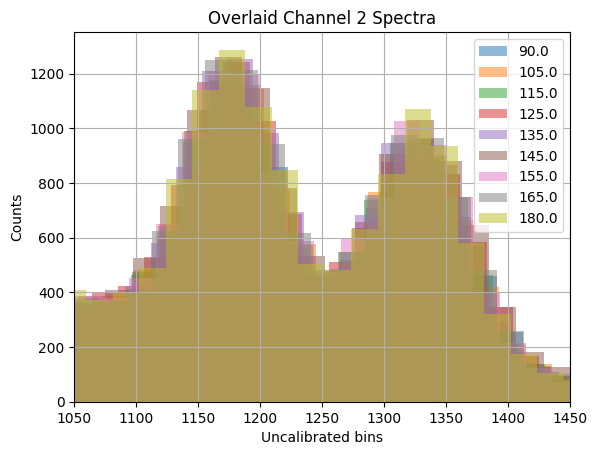

In [55]:
def plot_all_runs_with_gates(run_configs, key, xlim_left=None, xlim_right=None):
    num_channels = len(run_configs[0]['loaded_run'].channels)

    for chan_num in range(num_channels):
        chan_num = chan_num+1
        
        for run in run_configs:
            angle = run['angle']
            binned_counts = run[chan_num]['binned_counts']
            edges = run[chan_num][key]
            # plot
            plt.stairs(binned_counts, edges, alpha=0.5, label=f'{angle}', fill=True)

        plt.title(f'Overlaid Channel {chan_num} Spectra')
        plt.grid(True)
        plt.legend()
        plt.ylabel('Counts')
        plt.xlabel('Uncalibrated bins')

        if chan_num == 1:
            # plt.axvspan(1096, 1250, alpha=0.4)
            # plt.axvspan(1259, 1405, alpha=0.4)

            plt.axvspan(1106, 1240, alpha=0.4)
            plt.axvspan(1260, 1404, alpha=0.4)

            # plt.axvspan(1105, 1250, alpha=0.4)
            # plt.axvspan(1260, 1395, alpha=0.4)

        else:
            plt.axvspan(1106, 1240, alpha=0.4)
            plt.axvspan(1260, 1404, alpha=0.4)

            # plt.axvspan(1110, 1240, alpha=0.4)
            # plt.axvspan(1260, 1390, alpha=0.4)

        plt.xlim(xlim_left, xlim_right)
        plt.show()
        plt.close()

        for run in run_configs:
            angle = run['angle']
            binned_counts = run[chan_num]['binned_counts']
            edges = run[chan_num][key]
            # plot
            plt.stairs(binned_counts, edges, alpha=0.5, label=f'{angle}', fill=True)

        plt.title(f'Overlaid Channel {chan_num} Spectra')
        plt.grid(True)
        plt.legend()
        plt.ylabel('Counts')
        plt.xlabel('Uncalibrated bins')
        
        plt.xlim(xlim_left, xlim_right)

        plt.show()
        plt.close()

plot_all_runs_with_gates(RUN_CONFIGS_COINC_1June2026_CALIB, key='calib_edges', xlim_left=150, xlim_right=1600)
plot_all_runs_with_gates(RUN_CONFIGS_COINC_1June2026_CALIB, key='calib_edges', xlim_left=1050, xlim_right=1450)

# CHAN_1_TOL_1173 = 77
# CHAN_1_TOL_1332 = 73

# CHAN_2_TOL_1173 = 67
# CHAN_2_TOL_1332 = 72 

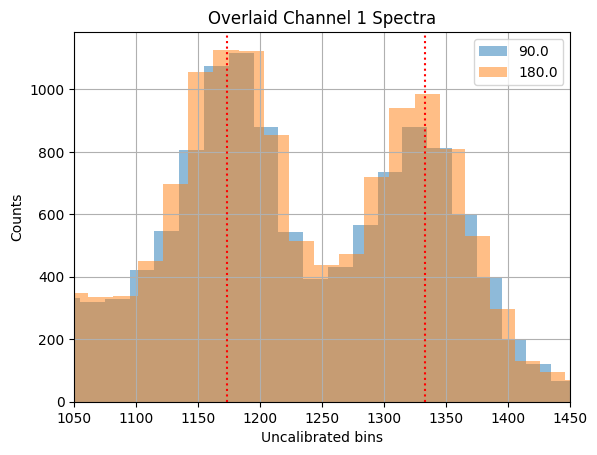

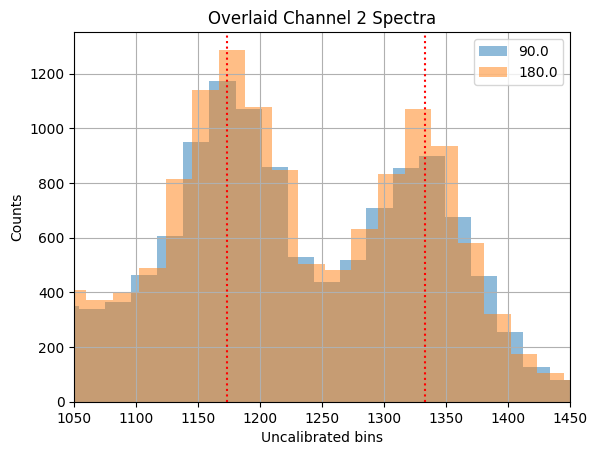

In [56]:
def plot_two_particular_angles(run_configs, key, index1, index2, xlim_left=None, xlim_right=None):
    num_channels = len(run_configs[0]['loaded_run'].channels)

    for chan_num in range(num_channels):
        chan_num = chan_num+1
        for run in [run_configs[index1], run_configs[index2]]:
            angle = run['angle']
            binned_counts = run[chan_num][f'binned_counts']
            edges = run[chan_num][f'{key}']
            # plot
            plt.stairs(binned_counts, edges, alpha=0.5, label=f'{angle}', fill=True)

        plt.title(f'Overlaid Channel {chan_num} Spectra')
        plt.grid(True)
        plt.legend()
        plt.ylabel('Counts')
        plt.xlabel('Uncalibrated bins')

        plt.xlim(xlim_left, xlim_right)

        plt.axvline(x=1173.228, color='red', linestyle=':', linewidth=1.5)
        plt.axvline(x=1332.492, color='red', linestyle=':', linewidth=1.5)

        plt.show()
        plt.close()

plot_two_particular_angles(RUN_CONFIGS_COINC_1June2026_CALIB, key='calib_edges', index1=0, index2=-1, xlim_left=1050, xlim_right=1450)

In [57]:
co60_tols = { 
1: dict(tol_1173=77, tol_1332=73), # in keV
2: dict(tol_1173=67, tol_1332=72)  # in keV
}

In [58]:
RUN_CONFIGS_COINC_1June2026_CALIB

[{'fname': 'C:\\Users\\pomar\\OneDrive\\Desktop\\Javier_Ang_Corr_Project\\06-01-2026/coincidence/co60_coincidence_trial_CH1_HV0_300+020_CH2+HV1_437+290_90deg_source_25cm_away_1June2026.dat',
  'angle': 90.0,
  'loaded_run': RunData(angle_deg=90.0, fname='C:\\Users\\pomar\\OneDrive\\Desktop\\Javier_Ang_Corr_Project\\06-01-2026/coincidence/co60_coincidence_trial_CH1_HV0_300+020_CH2+HV1_437+290_90deg_source_25cm_away_1June2026.dat', board_id=3067, channels={1: ChannelEvents(energy=array([133.11102513,  43.40294227,  97.27788746, ..., 126.43830311,
          46.82089607, 130.81768487]), pedestal=array([-0.00382124, -0.00406693, -0.00343385, ..., -0.00363221,
         -0.00259867, -0.00380318]), tthresh=array([180.29972341, 174.92318299, 184.78632163, ..., 184.03272666,
         185.81870179, 180.86551503])), 2: ChannelEvents(energy=array([ 56.95530545,  63.77344871, 107.6184054 , ..., 109.89811738,
          32.92479317,  53.45601171]), pedestal=array([-0.00445743, -0.00446958, -0.00238068

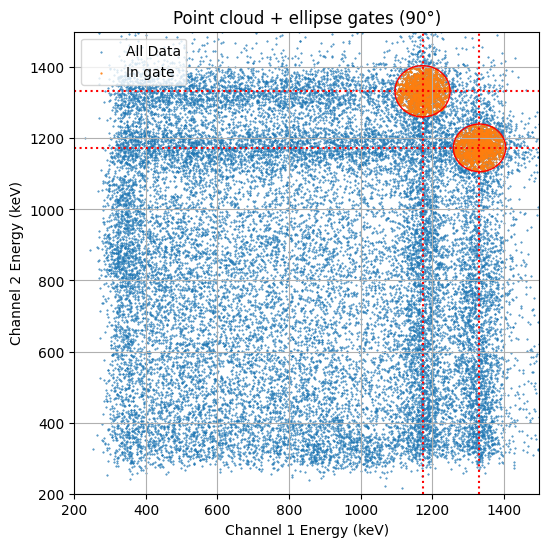

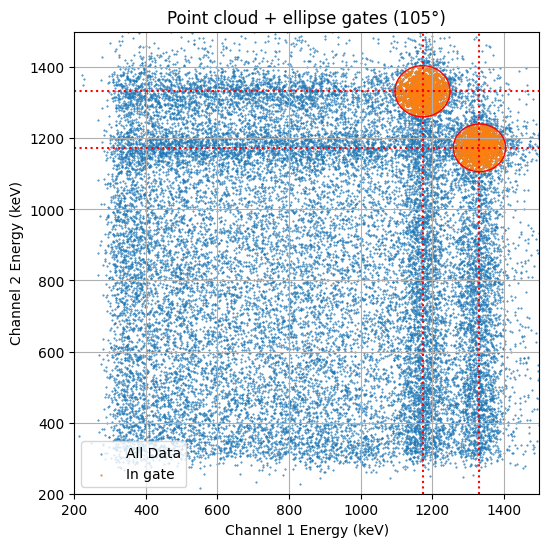

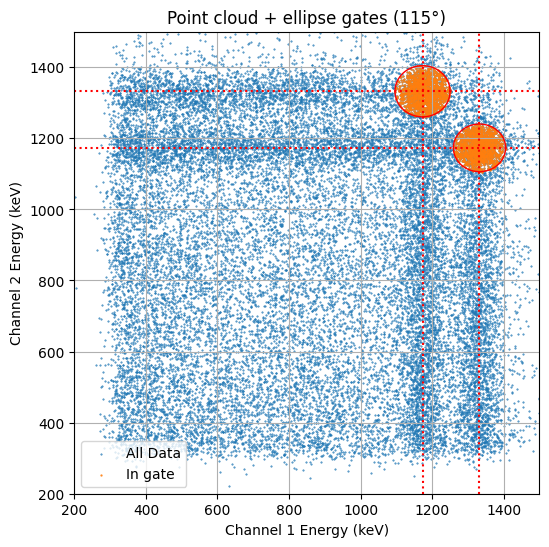

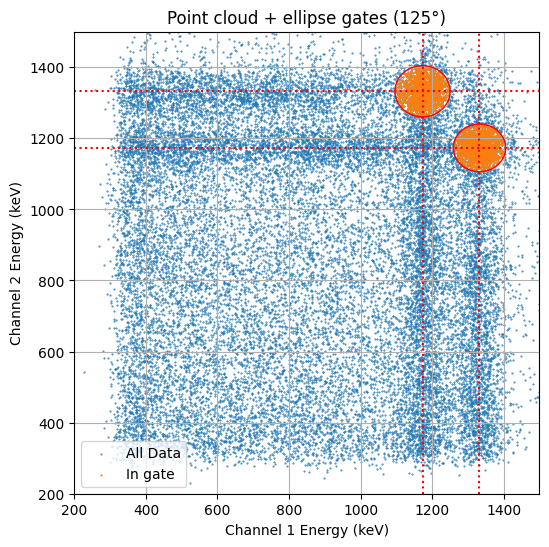

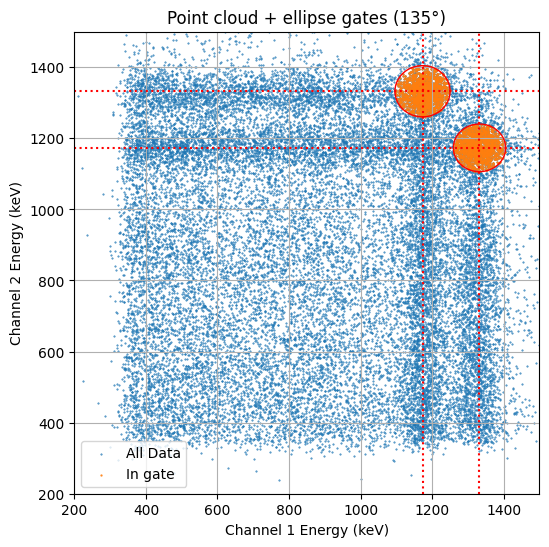

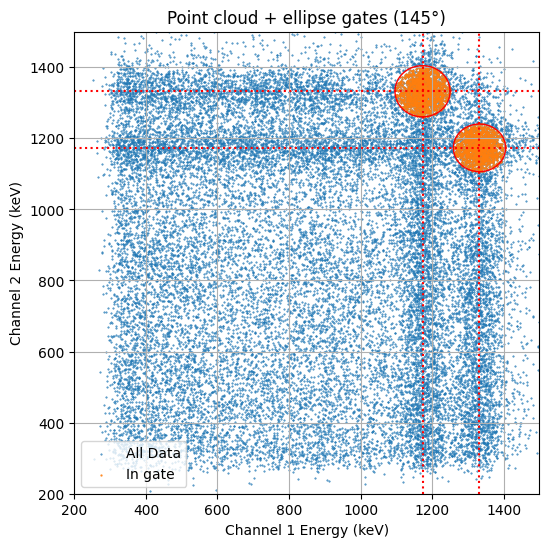

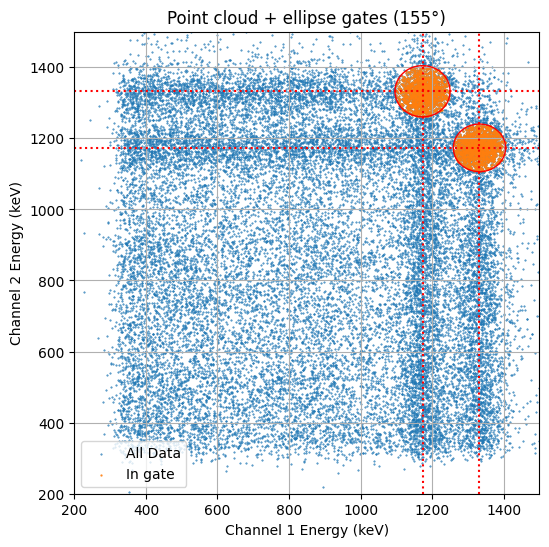

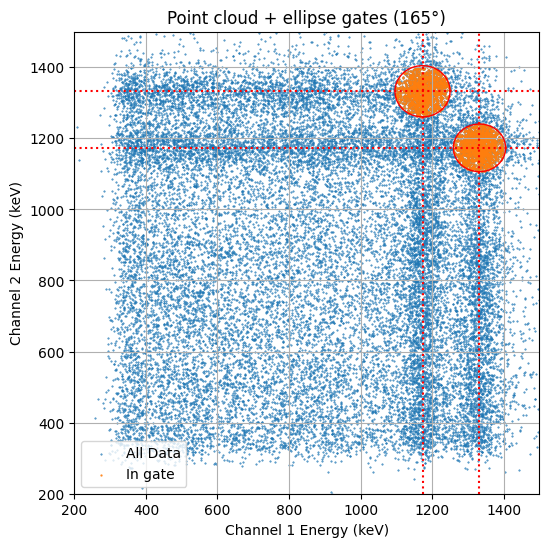

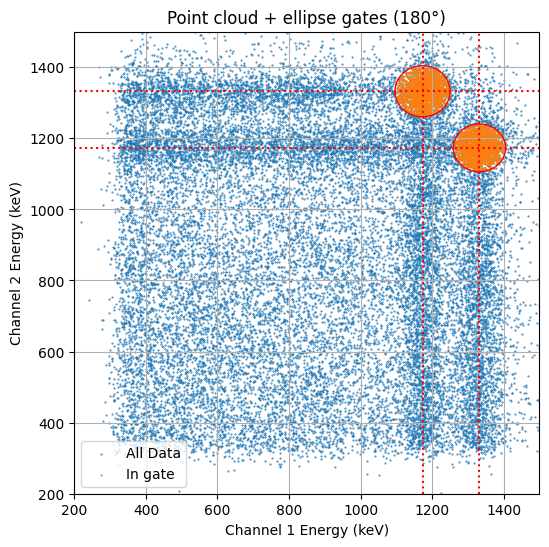

,N,N_unc,W,W_unc,N_in_1173_1332,N_in_1173_1332_unc,N_in_1332_1173,N_in_1332_1173_unc
angle,,,,,,,,
90.0,2617,51.156622,1.000000,0.000000,1324,36.386811,1293,35.958309
105.0,2673,51.701064,1.021399,0.028088,1405,37.483330,1268,35.608988
115.0,2832,53.216539,1.082155,0.029343,1441,37.960506,1391,37.296112
125.0,2856,53.441557,1.091326,0.029532,1428,37.788887,1428,37.788887
135.0,3002,54.790510,1.147115,0.030678,1528,39.089641,1474,38.392708
145.0,2841,53.301032,1.085594,0.029414,1501,38.742741,1340,36.606010
155.0,2932,54.147945,1.120367,0.030129,1456,38.157568,1476,38.418745
165.0,2949,54.304696,1.126863,0.030262,1489,38.587563,1460,38.209946
180.0,3001,54.781384,1.146733,0.030670,1562,39.522146,1439,37.934153


In [59]:
def trace_ellipse(
    mu1: float, 
    mu2: float, 
    a: float, 
    b: float, 
    *, 
    theta_rad: float = 0.0,
    n_points: int = 300, 
    color="red", 
    lw=2, 
    label=None
) -> None:

    """
    Plot an ellipse boundary in (E1,E2) keV space. Purely a visualization tool.

    mu1, mu2 : center (keV)
    a, b     : full-length of semi-axes (keV) 
    theta_rad: rotation angle in radians
    """

    t = np.linspace(0, 2*np.pi, n_points)

    # Parametric ellipse before rotation
    xp = a * np.cos(t)
    yp = b * np.sin(t)

    if theta_rad != 0.0:
        c = np.cos(theta_rad)
        s = np.sin(theta_rad)
        x =  c*xp - s*yp
        y =  s*xp + c*yp
    else:
        x, y = xp, yp

    E1 = mu1 + x
    E2 = mu2 + y

    plt.plot(E1, E2, color=color, lw=lw, label=label)

def my_debug_plot(run, res):
    angle = run["angle"]
    plt.figure(figsize=(6, 6))
    plt.scatter(res["E1_keV"], res["E2_keV"], s=0.2, alpha=1, label="All Data")
    plt.scatter(res["E1_gate_keV"], res["E2_gate_keV"], s=0.4, alpha=0.9, label="In gate")
    for p in res["ellipse_params_list"]:
        trace_ellipse(*p, theta_rad=0.0, lw=1)
    plt.title(f"Point cloud + ellipse gates ({angle:.0f}°)")
    plt.xlabel('Channel 1 Energy (keV)')
    plt.ylabel('Channel 2 Energy (keV)')
    plt.axvline(x=1173.228, color='red', linestyle=':', linewidth=1.5)
    plt.axvline(x=1332.492, color='red', linestyle=':', linewidth=1.5)
    plt.axhline(y=1173.228, color='red', linestyle=':', linewidth=1.5)
    plt.axhline(y=1332.492, color='red', linestyle=':', linewidth=1.5)
    plt.xlim(200, 1500)
    plt.ylim(200, 1500)
    plt.grid(True)
    plt.legend()
    plt.show()
    plt.close()

df = collect_coincidence_counts(
    RUN_CONFIGS_COINC_1June2026_CALIB,
    co60_tols=co60_tols,
    norm_angle=90.0,
    debug_plot_fn=my_debug_plot,
)

display(df)

In [60]:
def co60_angular_correlation(theta_deg: np.ndarray) -> np.ndarray:
    """Theoretical Co-60 angular correlation function W(theta)."""
    theta = np.deg2rad(theta_deg)
    return 1 + (1/8)*np.cos(theta)**2 + (1/24)*np.cos(theta)**4

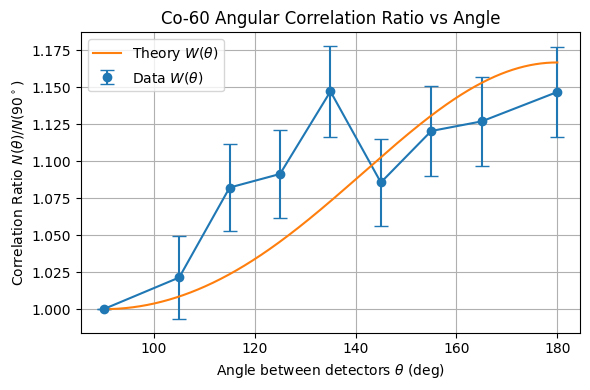

In [61]:
norm_angle = 90.0

angles = df.index.to_numpy(dtype=float)
fine_angles = np.linspace(angles[0], angles[-1], 10**3)

corr_ratio = df["W"].to_numpy(dtype=float)
corr_ratio_unc = df["W_unc"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    angles, corr_ratio, yerr=corr_ratio_unc,
    capsize=5, fmt="o", color="C0", label=r"Data $W(\theta)$",
)

ax.plot(
    angles, corr_ratio, color="C0"
)

ax.plot(
    fine_angles, co60_angular_correlation(fine_angles),
    color="C1", label=r"Theory $W(\theta)$",
)

ax.set_xlabel(r"Angle between detectors $\theta$ (deg)")
ax.set_ylabel(r"Correlation Ratio $N(\theta)/N(90^\circ)$")
ax.set_title("Co-60 Angular Correlation Ratio vs Angle")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

In [62]:
# use the same name as the .pkl to save the .csv into "/results/"
df.to_csv("../results/coincidence_trial_1June2026_load_run.csv")

# Single trigger sanity-check 

In [63]:
CH1_TRIGGER_RUN_CONFIGS_1June2026_BINNED = establish_binning(CH1_TRIGGER_RUN_CONFIGS_1June2026)

CH2_TRIGGER_RUN_CONFIGS_1June2026_BINNED = establish_binning(CH2_TRIGGER_RUN_CONFIGS_1June2026)

In [64]:
CH1_TRIGGER_RUN_CONFIGS_1June2026_CALIB = copy_calibration(
    CH1_TRIGGER_RUN_CONFIGS_1June2026_BINNED, 
    RUN_CONFIGS_COINC_1June2026_CALIB)

CH2_TRIGGER_RUN_CONFIGS_1June2026_CALIB = copy_calibration(
    CH2_TRIGGER_RUN_CONFIGS_1June2026_BINNED, 
    RUN_CONFIGS_COINC_1June2026_CALIB)

In [65]:
ch1_df = collect_single_trigger_counts(
    CH1_TRIGGER_RUN_CONFIGS_1June2026_CALIB,
    1,
    co60_tols)

ch2_df = collect_single_trigger_counts(
    CH2_TRIGGER_RUN_CONFIGS_1June2026_CALIB,
    2,
    co60_tols)

display(ch1_df)
display(ch2_df)

,N_comb,N_comb_unc,N_comb_norm,N_comb_unc_norm,N_1173,N_1173_unc,N_1173_norm,N_1173_unc_norm,N_1332,N_1332_unc,N_1332_norm,N_1332_unc_norm,W_comb,W_comb_unc,W_1173,W_1173_unc,W_1332,W_1332_unc
angle,,,,,,,,,,,,,,,,,,
90.0,10152,100.757134,0.338682,0.003361,5682,75.379042,0.189558,0.002515,4470,66.858059,0.149124,0.002230,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
105.0,10133,100.662803,0.338048,0.003358,5756,75.868307,0.192027,0.002531,4377,66.158900,0.146022,0.002207,1.001875,0.014069,0.987144,0.018461,1.021247,0.021716
115.0,10489,102.415819,0.349925,0.003417,5953,77.155687,0.198599,0.002574,4536,67.349833,0.151326,0.002247,0.967871,0.013475,0.954477,0.017702,0.985450,0.020769
125.0,10242,101.202767,0.341685,0.003376,5853,76.504902,0.195263,0.002552,4389,66.249528,0.146422,0.002210,0.991213,0.013882,0.970784,0.018080,1.018455,0.021642
135.0,10071,100.354372,0.335980,0.003348,5614,74.926631,0.187289,0.002500,4457,66.760767,0.148691,0.002227,1.008043,0.014177,1.012113,0.019046,1.002917,0.021230
145.0,10213,101.059388,0.340717,0.003371,5752,75.841941,0.191893,0.002530,4461,66.790718,0.148824,0.002228,0.994027,0.013931,0.987830,0.018477,1.002017,0.021206
155.0,10088,100.439036,0.336547,0.003351,5702,75.511589,0.190225,0.002519,4386,66.226883,0.146322,0.002209,1.006344,0.014147,0.996492,0.018679,1.019152,0.021661
165.0,9875,99.373035,0.329441,0.003315,5509,74.222638,0.183786,0.002476,4366,66.075714,0.145655,0.002204,1.028051,0.014530,1.031403,0.019502,1.023820,0.021785
180.0,10103,100.513681,0.337048,0.003353,5648,75.153177,0.188424,0.002507,4455,66.745786,0.148624,0.002227,1.004850,0.014121,1.006020,0.018903,1.003367,0.021242


,N_comb,N_comb_unc,N_comb_norm,N_comb_unc_norm,N_1173,N_1173_unc,N_1173_norm,N_1173_unc_norm,N_1332,N_1332_unc,N_1332_norm,N_1332_unc_norm,W_comb,W_comb_unc,W_1173,W_1173_unc,W_1332,W_1332_unc
angle,,,,,,,,,,,,,,,,,,
90.0,10135,100.672737,0.338635,0.003364,5632,75.046652,0.188179,0.002507,4503,67.104396,0.150456,0.002242,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
105.0,9874,99.368003,0.329914,0.003320,5498,74.148500,0.183701,0.002477,4376,66.151342,0.146213,0.002210,1.026433,0.014514,1.024372,0.019421,1.029022,0.021843
115.0,9875,99.373035,0.329948,0.003320,5496,74.135012,0.183635,0.002477,4379,66.174013,0.146313,0.002211,1.026329,0.014512,1.024745,0.019430,1.028317,0.021824
125.0,9951,99.754699,0.332487,0.003333,5657,75.213031,0.189014,0.002513,4294,65.528620,0.143473,0.002189,1.018491,0.014373,0.995581,0.018740,1.048673,0.022368
135.0,10393,101.946064,0.347255,0.003406,5745,75.795778,0.191954,0.002533,4648,68.176242,0.155301,0.002278,0.975176,0.013614,0.980331,0.018383,0.968804,0.020258
145.0,9855,99.272353,0.329279,0.003317,5561,74.572113,0.185806,0.002492,4294,65.528620,0.143473,0.002189,1.028412,0.014549,1.012767,0.019146,1.048673,0.022368
155.0,10210,101.044545,0.341141,0.003376,5689,75.425460,0.190083,0.002520,4521,67.238382,0.151058,0.002247,0.992654,0.013919,0.989981,0.018609,0.996019,0.020970
165.0,10171,100.851376,0.339838,0.003370,5562,74.578817,0.185840,0.002492,4609,67.889616,0.153998,0.002268,0.996461,0.013986,1.012585,0.019142,0.977002,0.020471
180.0,10218,101.084123,0.341408,0.003377,5647,75.146524,0.188680,0.002511,4571,67.609171,0.152728,0.002259,0.991877,0.013905,0.997344,0.018782,0.985124,0.020684


KeyError: 'N'

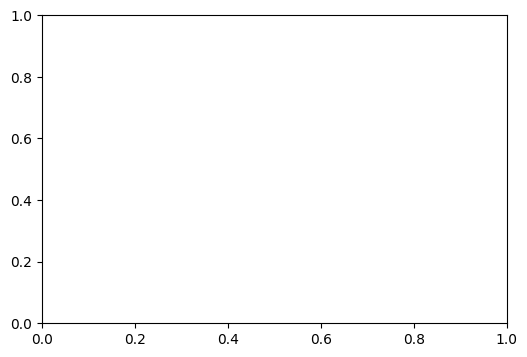

In [66]:
angles = ch1_df.index.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))

ch1_n = ch1_df["N"].to_numpy(dtype=float)
ch1_n_unc = ch1_df["N_unc"].to_numpy(dtype=float)

ch2_n = ch2_df["N"].to_numpy(dtype=float)
ch2_n_unc = ch2_df["N_unc"].to_numpy(dtype=float)

ax.errorbar(
    angles, ch1_n, yerr=ch1_n_unc,
    capsize=5, fmt="o", color="C0", label=r"Channel 1 $N(\theta)$",
)
ax.plot(angles, ch1_n, color="C0")

ax.errorbar(
    angles, ch2_n, yerr=ch2_n_unc,
    capsize=5, fmt="o", color="C1", label=r"Channel 2 $N(\theta)$",
)
ax.plot(angles, ch2_n, color="C1")

ax.set_xlabel(r"Angle between detectors $\theta$ (deg)")
ax.set_ylabel(r"Number of Events in 1173 and 1332 keV peaks $N(\theta)$")
ax.set_title("Co-60 Number of Events vs Angle")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()


angles = ch1_df.index.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))

ch1_n = ch1_df["N_norm"].to_numpy(dtype=float)
ch1_n_unc = ch1_df["N_unc_norm"].to_numpy(dtype=float)

ch2_n = ch2_df["N_norm"].to_numpy(dtype=float)
ch2_n_unc = ch2_df["N_unc_norm"].to_numpy(dtype=float)

ax.errorbar(
    angles, ch1_n, yerr=ch1_n_unc,
    capsize=5, fmt="o", color="C0", label=r"Channel 1",
)
ax.plot(angles, ch1_n, color="C0")

ax.errorbar(
    angles, ch2_n, yerr=ch2_n_unc,
    capsize=5, fmt="o", color="C1", label=r"Channel 2",
)
ax.plot(angles, ch2_n, color="C1")

ax.set_xlabel(r"Angle between detectors $\theta$ (deg)")
ax.set_ylabel(r"Normalized Event Number in 1173 & 1332 keV peaks")
ax.set_title("Co-60 Number of Events vs Angle")
ax.grid(True)
ax.legend()
# fig.tight_layout()
plt.show()

In [ ]:
ch1_df.to_csv("../results/CH1_trig_trial_1June2026_load_run_single_trigger.csv")
ch2_df.to_csv("../results/CH2_trig_trial_1June2026_load_run_single_trigger.csv")